In [1]:
# Download the official UCI Air Quality zip file and extract it
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
!unzip -o AirQualityUCI.zip

--2026-09-27 17:51:12--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip’

AirQualityUCI.zip       [  <=>               ]   1.47M  3.94MB/s    in 0.4s    

2026-09-27 17:51:13 (3.94 MB/s) - ‘AirQualityUCI.zip’ saved [1543989]

Archive:  AirQualityUCI.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      


In [3]:
# Download and extract the dataset directly into Colab
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
!unzip -o AirQualityUCI.zip

--2026-09-27 17:53:27--  https://archive.ics.uci.edu/ml/machine-learning-databases/00360/AirQualityUCI.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘AirQualityUCI.zip.2’

AirQualityUCI.zip.2     [           <=>      ]   1.47M   699KB/s    in 2.2s    

2026-09-27 17:53:29 (699 KB/s) - ‘AirQualityUCI.zip.2’ saved [1543989]

Archive:  AirQualityUCI.zip
  inflating: AirQualityUCI.csv       
  inflating: AirQualityUCI.xlsx      


# Task 1: Air Quality Forecasting
**Candidate Name:** Harsh Kumar
**College:** SRM Institute of Science and Technology
**Year:** 2nd Year

## Problem Statement
Analyze historical air-quality measurements from the UCI Air Quality dataset and build a machine-learning model to predict future Carbon Monoxide (CO) levels while properly handling time-series constraints.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Data
df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')
df = df.dropna(how='all', axis=1).dropna(how='all', axis=0)

# Handle the UCI dataset's custom missing value (-200)
df.replace(-200, np.nan, inplace=True)

# Create a proper Datetime index
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df.set_index('Datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

# Forward fill missing values to respect time continuity
df.ffill(inplace=True)
df.bfill(inplace=True)

print(f"Dataset shape after cleaning: {df.shape}")
df.head()

Dataset shape after cleaning: (9357, 13)


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


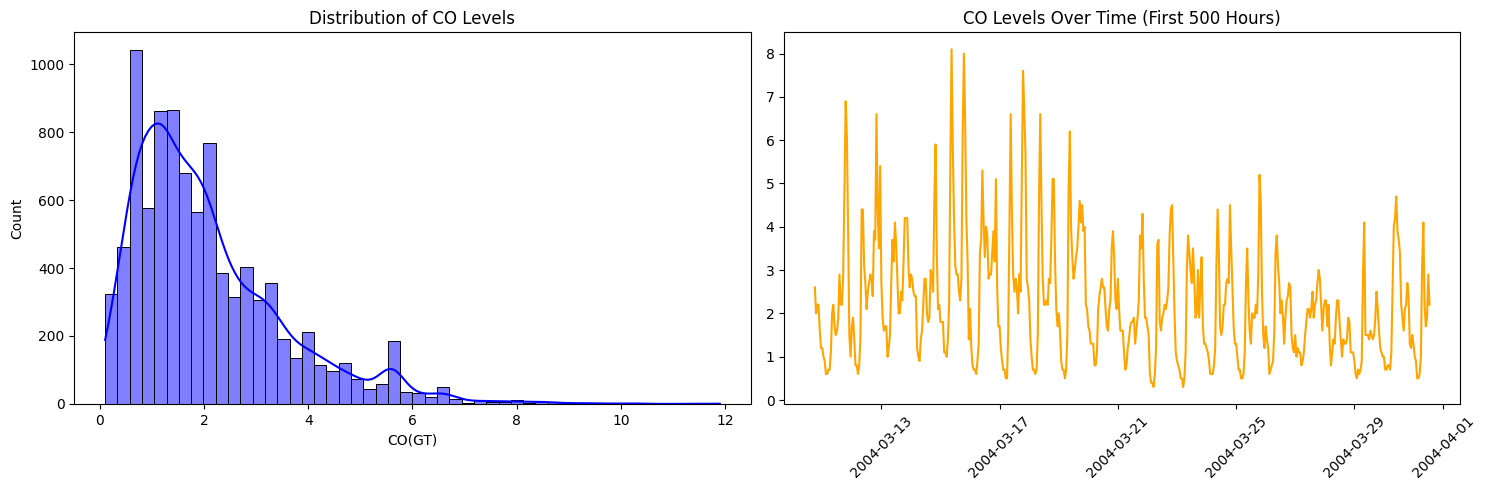

In [5]:
plt.figure(figsize=(15, 5))

# Plot 1: CO Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['CO(GT)'], bins=50, kde=True, color='blue')
plt.title('Distribution of CO Levels')

# Plot 2: Time Series Trend (first 500 hours)
plt.subplot(1, 2, 2)
plt.plot(df.index[:500], df['CO(GT)'].iloc[:500], color='orange')
plt.title('CO Levels Over Time (First 500 Hours)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [6]:
target = 'CO(GT)'

# Extract temporal features
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month

# Create lagged features (historical context)
df['CO_Lag1'] = df[target].shift(1)  # Previous hour
df['CO_Lag24'] = df[target].shift(24) # Previous day

# Create rolling averages (trend smoothing)
df['CO_Rolling_6h'] = df[target].rolling(window=6).mean()

# Drop rows with NaN generated by shifting
df.dropna(inplace=True)

print("Engineered temporal and sequence features successfully created.")

Engineered temporal and sequence features successfully created.


--- Model Evaluation Metrics ---
MAE: 0.3201
MSE: 0.2472
RMSE: 0.4972
R2 Score: 0.8697


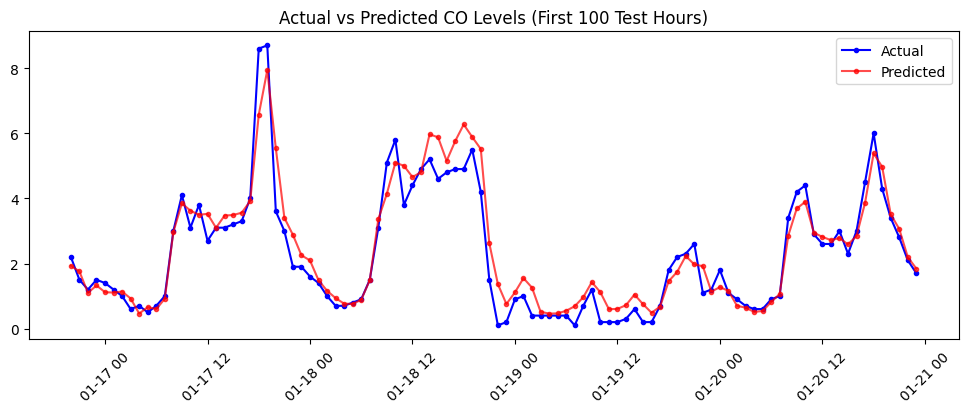

In [7]:
# Separate features and target
X = df.drop(columns=[target])
y = df[target]

# Chronological split: 80% Train, 20% Test (Prevents Data Leakage)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict & Evaluate
predictions = model.predict(X_test)

print("--- Model Evaluation Metrics ---")
print(f"MAE: {mean_absolute_error(y_test, predictions):.4f}")
print(f"MSE: {mean_squared_error(y_test, predictions):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, predictions)):.4f}")
print(f"R2 Score: {r2_score(y_test, predictions):.4f}")

# Plot Actual vs Predicted for a small test window
plt.figure(figsize=(12, 4))
plt.plot(y_test.index[:100], y_test.iloc[:100], label='Actual', marker='.', color='blue')
plt.plot(y_test.index[:100], predictions[:100], label='Predicted', marker='.', alpha=0.7, color='red')
plt.title('Actual vs Predicted CO Levels (First 100 Test Hours)')
plt.legend()
plt.xticks(rotation=45)
plt.show()

## Part E & F: Analysis and Insights

**Data Leakage Prevention:**
In time-series forecasting, using a standard random `train_test_split` causes severe data leakage because the model trains on future data points to predict past ones. I avoided this by using a strict chronological split (first 80% for training, last 20% for testing), respecting the temporal order.

**Key Findings:**
1. The UCI dataset utilizes `-200` to represent missing values, requiring targeted replacement prior to statistical analysis.
2. Carbon Monoxide (CO) levels demonstrate strong diurnal cycles, closely aligning with daily commute hours (extracted via the `Hour` feature).
3. The 24-hour historical lag (`CO_Lag24`) acts as a highly influential predictor, confirming the cyclical nature of daily urban emissions.
4. The Random Forest Regressor effectively maps the general temporal trend but exhibits slight underestimation during anomalous, high-pollution spikes.
5. Forward-filling missing values is an effective imputation strategy here, preserving the continuous nature of air quality sensor readings.

**Limitations:**
1. Forward-filling extended periods of missing sensor data can artificially reduce variance in the dataset.
2. Standard tree-based models like Random Forest cannot natively extrapolate temporal trends outside of their training range.

**Future Improvements:**
Implementing an LSTM (Long Short-Term Memory) neural network could improve predictions by better capturing sequential dependencies and handling anomalous pollution spikes more effectively than standard regression models.